<a href="https://colab.research.google.com/github/cactus1386/NationalCard-ImageProccessing/blob/main/idcard_main_method2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install and import Libraries

In [2]:
! pip install ultralytics hezar insightface onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 19.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s e

In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import os
import pandas as pd
import re
from hezar.models import Model
from insightface.app import FaceAnalysis

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [1]:
!git clone https://github.com/cactus1386/NationalCard-ImageProccessing.git

Cloning into 'NationalCard-ImageProccessing'...
remote: Enumerating objects: 652, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 652 (delta 16), reused 23 (delta 8), pack-reused 613 (from 2)
Receiving objects: 100% (652/652), 215.27 MiB | 42.51 MiB/s, done.
Resolving deltas: 100% (201/201), done.


# Read kibord dataset

In [ ]:
import gdown
import zipfile
import os

In [ ]:
file_id = "1EP7JhNFoLtlmJCabhrpTYOkMJ2c_OyMM"
dataset_zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

In [ ]:
gdown.download(f"https://drive.google.com/uc?id={file_id}", dataset_zip_path, quiet=False)

with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset downloaded and extracted successfully!")


Downloading...
From (original): https://drive.google.com/uc?id=1EP7JhNFoLtlmJCabhrpTYOkMJ2c_OyMM
From (redirected): https://drive.google.com/uc?id=1EP7JhNFoLtlmJCabhrpTYOkMJ2c_OyMM&confirm=t&uuid=6f05fa74-3d7e-462a-99b3-fd8490a30692
To: /content/dataset.zip
100%|██████████| 539M/539M [00:10<00:00, 52.7MB/s]


✅ Dataset downloaded and extracted successfully!


In [ ]:
print("Sample files:", os.listdir(extract_path)[:5])

Sample files: ['2832.PNG', '1443.jpg', '650.PNG', '5.PNG', '1601.jpg']


# Set model and path

In [10]:
detector = FaceAnalysis(name='buffalo_l') # set face detector
detector.prepare(ctx_id=0, det_size=(640, 640))
objects_model = YOLO('/content/NationalCard-ImageProccessing/models/TextDetection.pt') # set yolo model for object detection
card_model = YOLO('/content/NationalCard-ImageProccessing/models/CardDetection.pt') # set yolo model for card detection
seg_model = YOLO("/content/NationalCard-ImageProccessing/models/card_segmentation.pt") # set yolo model for segmentation
logo_model = YOLO('/content/NationalCard-ImageProccessing/models/RotateIDCard.pt')
path = '/content/NationalCard-ImageProccessing/models' # set path for finetuned ocr
hezar = Model.load("hezarai/crnn-fa-printed-96-long") # set hezar ocr model
hezar.save(path)
hezar_ocr = Model.load(path)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


# Rotation Code

In [ ]:
def rotation(path):
    image = cv2.imread(path) # set image
    results = card_model(image) # run card yolo model for image

    if len(results[0].boxes) == 0: # if cant recognize card
        print("No card detected!")
        return None

    # set 4 corner location
    x1, y1, x2, y2 = map(int, results[0].boxes[0].xyxy[0])
    cropped_card = image[y1:y2, x1:x2]

    # detect face in the cropped card
    faces = detector.get(cropped_card)

    # check for faces
    if faces:
        x1, y1, x2, y2 = map(int, faces[0]['bbox'])  # get face bounding box
        w, h = x2 - x1, y2 - y1
        face_center = (x1 + w // 2, y1 + h // 2)  # face center
        card_center = (cropped_card.shape[1] // 2, cropped_card.shape[0] // 2)  # card center

        # calculate rotation angle
        angle = np.arctan2(face_center[1] - card_center[1], face_center[0] - card_center[0]) * (180 / np.pi) + 180
        rotation_matrix = cv2.getRotationMatrix2D(card_center, angle, 1.0)
        rotated = cv2.warpAffine(cropped_card, rotation_matrix, (cropped_card.shape[1], cropped_card.shape[0]))

        rotated_per = segmentation_perspective(rotated)

        return rotated_per  # return image

    corrected_card = segmentation_perspective(cropped_card)

    return corrected_card  # if cant find face


# Use other model for text detection (Hezar)

In [ ]:
def process_img(img):
    data = {}
    results = objects_model(img) # set part of object detection yolo model

    # dict for each box conf
    box_confidences = {}

    for result in results:
        boxes = result.boxes
        for box in boxes:
            xyxy = box.xyxy[0]
            x1, y1, x2, y2 = map(int, xyxy.tolist()) # set corner locations
            label = result.names[int(box.cls)] # set label
            conf = float(box.conf)  # set conf

            cropped_img = img[max(0, y1-3):y2+3, max(0, x1-3):x2+3] # cropped image location (with more nums for better conf)
            cv2_imshow(cropped_img)

            ocr_result = hezar_ocr.predict(cropped_img)  # read text with ocr

            if ocr_result:  # check if OCR returned results
                text_list = []
                for item in ocr_result:
                    text_list.append(item['text'])
                text = " ".join(text_list)  # retrun text
            else:
                text = "" # return empty str

            # best conf text (if have more than one)
            if label in box_confidences:
                if conf > box_confidences[label][1]:
                    box_confidences[label] = (text, conf)
            else:
                box_confidences[label] = (text, conf)

    # print label, text and conf
    for label, (text, conf) in box_confidences.items():
        print(f"Label: {label}, Text: {text}, Confidence: {conf}")
        data[label] = text.strip()

    return data

# Perspective

In [70]:
def segmentation_perspective(image):
    # run segmentation model to detect objects and their masks
    results = seg_model(image)

    for r in results:
        masks = r.masks
        if masks is not None:  # check if any masks were detected
            for mask in masks.xy:  # process each mask coordinates
                # convert mask points to integer array for OpenCV
                pts = np.array(mask, dtype=np.int32)

                # get image dimensions and create a blank binary mask
                height, width = image.shape[:2]
                mask_binary = np.zeros((height, width), dtype=np.uint8)
                # fill the mask area with white (255)
                cv2.fillPoly(mask_binary, [pts], 255)

                # find contours in the binary mask and select the largest one
                contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                contour = max(contours, key=cv2.contourArea)

                # approximate the contour to a polygon
                epsilon = 0.02 * cv2.arcLength(contour, True)  # precision for approximation
                approx = cv2.approxPolyDP(contour, epsilon, True)

                # check if the shape has exactly 4 corners
                if len(approx) == 4:
                    # reshape and sort corners: top-left, top-right, bottom-right, bottom-left
                    corners = approx.reshape(4, 2)
                    corners = sorted(corners, key=lambda x: x[1])  # sort by y-coordinate
                    top_corners = sorted(corners[:2], key=lambda x: x[0])  # sort top by x
                    bottom_corners = sorted(corners[2:], key=lambda x: x[0])  # sort bottom by x
                    ordered_corners = [top_corners[0], top_corners[1], bottom_corners[1], bottom_corners[0]]

                    # calculate bounding rectangle and aspect ratio
                    print(cv2.boundingRect(contour))
                    x, y, w, h = cv2.boundingRect(contour)
                    aspect_ratio = w / h
                    # set output size based on aspect ratio
                    if aspect_ratio > 1:  # wider than tall
                        width = 1180
                        height = int(width / aspect_ratio)
                    else:  # taller than wide
                        height = 750
                        width = int(height * aspect_ratio)

                    # define ideal rectangular coordinates for the output
                    ideal_coords = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype="float32")

                    # compute perspective transformation matrix
                    matrix = cv2.getPerspectiveTransform(np.array(ordered_corners, dtype="float32"), ideal_coords)

                    # apply sharpening filter to enhance edges
                    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
                    sharpened = cv2.filter2D(image, -1, kernel)

                    # warp the sharpened image to the corrected perspective
                    corrected_image = cv2.warpPerspective(sharpened, matrix, (width, height), flags=cv2.INTER_LANCZOS4)

                    # display the result
                    cv2_imshow(corrected_image)
                    cv2.imwrite('/content/test/test.jpg', corrected_image)

                    result = logo_model(corrected_image)
                    result = result[0]
                    boxes = result.boxes.xyxy.cpu().numpy().astype(int)
                    confidences = result.boxes.conf.cpu().numpy()
                    class_ids = result.boxes.cls.cpu().numpy().astype(int)
                    class_names = result.names

                    image = corrected_image

                    flag_x1, flag_y1, flag_x2, flag_y2 = boxes[0]
                    flag_center_x = (flag_x1 + flag_x2) // 2
                    flag_center_y = (flag_y1 + flag_y2) // 2


                    flag_class_id = class_ids[0]
                    flag_class_name = class_names[flag_class_id]


                    logo_x1, logo_y1, logo_x2, logo_y2 = boxes[1]
                    logo_center_x = (logo_x1 + logo_x2) // 2
                    logo_center_y = (logo_y1 + logo_y2) // 2

                    logo_class_id = class_ids[1]
                    logo_class_name = class_names[logo_class_id]

                    cv2.rectangle(image, (flag_x1, flag_y1), (flag_x2, flag_y2), (0, 255, 0), 2)
                    cv2.putText(image, flag_class_name, (flag_x1, flag_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                    cv2.circle(image, (flag_center_x, flag_center_y), 5, (0, 255, 0), -1)

                    cv2.rectangle(image, (logo_x1, logo_y1), (logo_x2, logo_y2), (255, 0, 0), 2)
                    cv2.putText(image, logo_class_name, (logo_x1, logo_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                    cv2.circle(image, (logo_center_x, logo_center_y), 5, (255, 0, 0), -1)


                    slope = (logo_center_y - flag_center_y) / (logo_center_x - flag_center_x)
                    angle = np.arctan2(slope, 1)


                    rotation_angle = np.degrees(angle)

                    center = (image.shape[1] // 2, image.shape[0] // 2)



                    print(rotation_angle)

                    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
                    rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

                    new_center = (rotated_image.shape[1] // 2, rotated_image.shape[0] // 2)



                    cv2_imshow(rotated_image)
                    r_new = logo_model.predict(source=rotated_image, show=False, conf=0.2)
                    result = r_new[0]

                    try:
                      boxes = result.boxes.xyxy.cpu().numpy().astype(int)


                      flag_x1n, flag_y1n, flag_x2n, flag_y2n = boxes[0]
                      logo_x1n, logo_y1n, logo_x2n, logo_y2n = boxes[1]

                      new_flag_center_x = (flag_x1n + flag_x2n) // 2
                      new_flag_center_y = (flag_y1n + flag_y2n) // 2
                      new_logo_center_x = (logo_x1n + logo_x2n) // 2
                      new_logo_center_y = (logo_y1n + logo_y2n) // 2

                      if center[1] > new_logo_center_y and center[1] > new_flag_center_y :
                        print(center[0], center[1])
                        print(logo_center_y)
                        rotated_image = cv2.rotate(rotated_image, cv2.ROTATE_180)
                    except:
                      pass
                    return corrected_image
                else:
                    # return original image if shape isnt a quadrilateral
                    return image
        else:
            # return original image if no masks are detected
            return image


0: 480x640 1 Card, 46.9ms
Speed: 6.5ms preprocess, 46.9ms inference, 16.3ms postprocess per image at shape (1, 3, 480, 640)
(505, 1054, 3433, 1815)


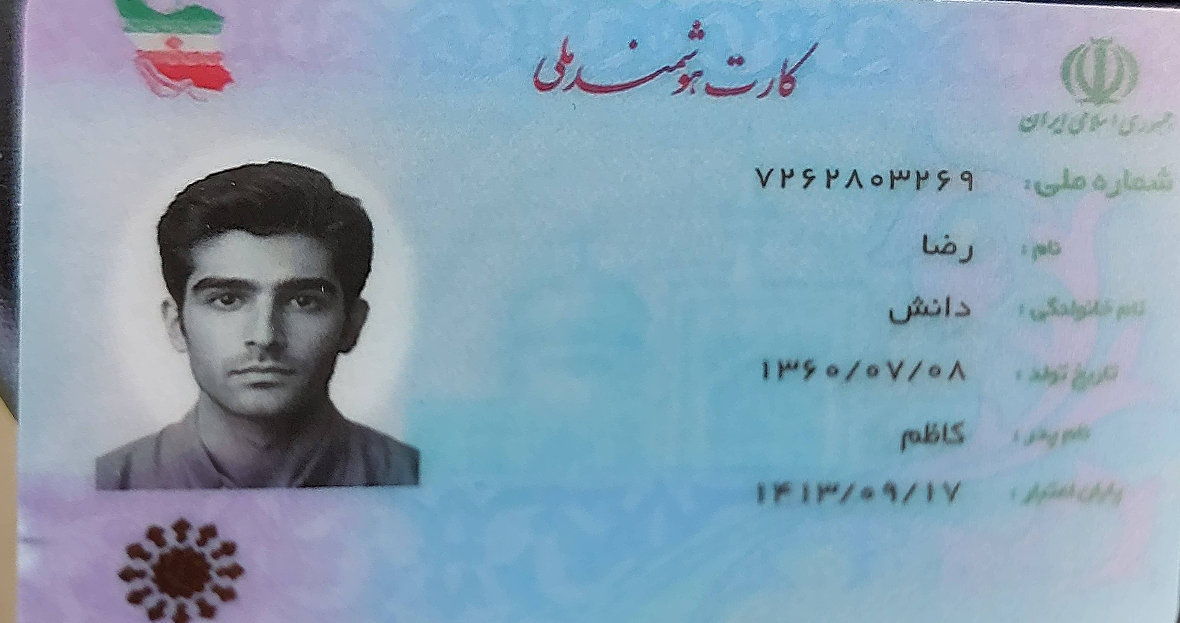


0: 352x640 1 Flag, 1 Logo, 56.2ms
Speed: 3.3ms preprocess, 56.2ms inference, 2.3ms postprocess per image at shape (1, 3, 352, 640)
1.166633827667933


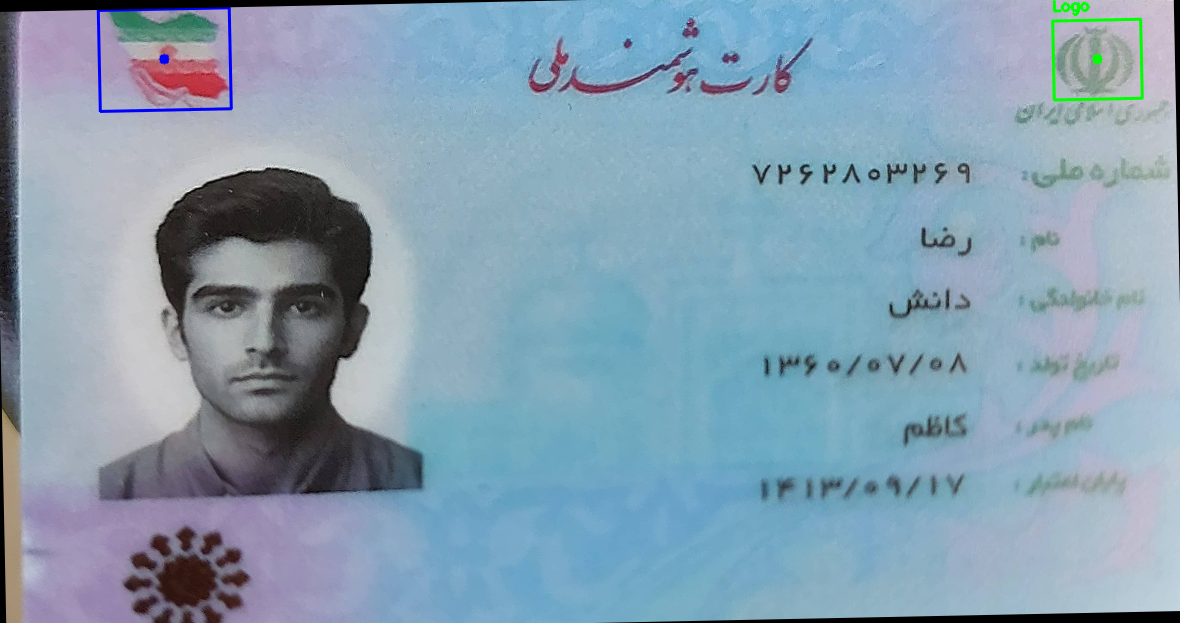


0: 352x640 2 Flags, 73.1ms
Speed: 7.0ms preprocess, 73.1ms inference, 2.4ms postprocess per image at shape (1, 3, 352, 640)
590 311
50


In [ ]:
img = cv2.imread('/content/image/1022.jpg')

img2 = segmentation_perspective(img)


0: 480x640 2 Cards, 24.3ms
Speed: 4.8ms preprocess, 24.3ms inference, 10.9ms postprocess per image at shape (1, 3, 480, 640)
(1979, 852, 1728, 2595)


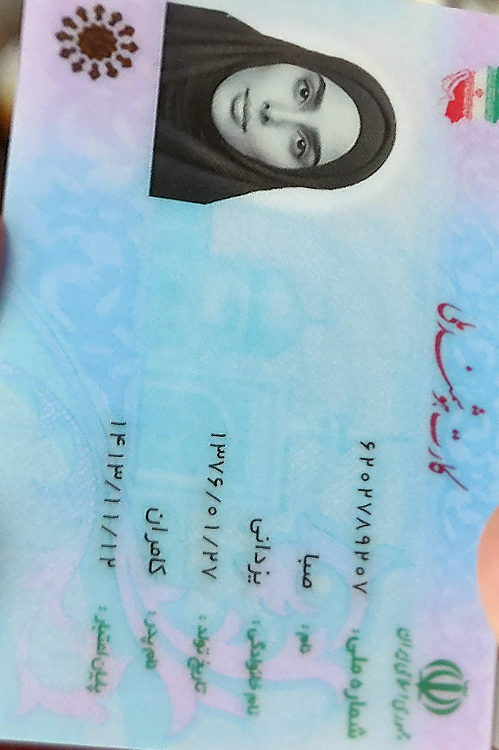


0: 640x448 1 Flag, 1 Logo, 108.6ms
Speed: 16.5ms preprocess, 108.6ms inference, 7.6ms postprocess per image at shape (1, 3, 640, 448)
-87.57366416839764


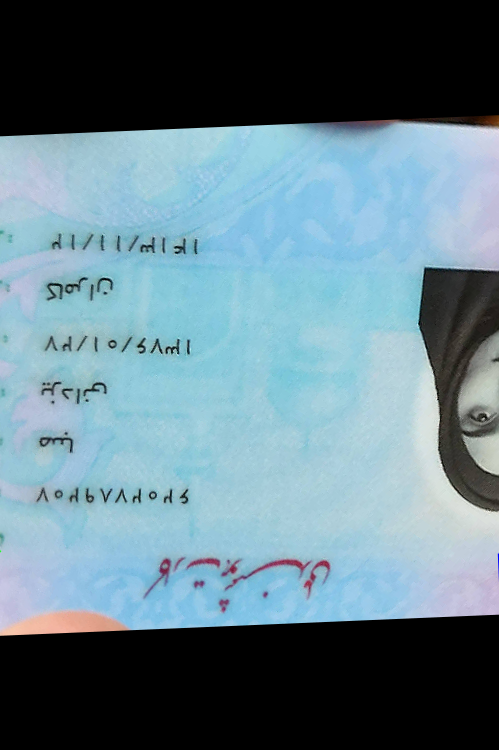


0: 640x448 (no detections), 77.2ms
Speed: 9.6ms preprocess, 77.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)


In [72]:
img = cv2.imread('/content/image/1084.jpg')

img2 = segmentation_perspective(img)

# Call function and use it

In [ ]:
def detect(folder):
    detected = []  # لیست برای ذخیره داده‌ها
    processed_count = 0  # شمارنده عکس‌های بررسی‌شده

    for img in os.listdir(folder):
        if img.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.heic')):
            processed_count += 1  # افزایش شمارنده

            # چاپ تعداد عکس‌های بررسی‌شده هر 10 تا
            if processed_count % 10 == 0:
                print(f"تعداد عکس‌های بررسی‌شده: {processed_count}")

            img_path = os.path.join(folder, img)
            data = {'image_id': img.split('.')[0], 'national_id': '', 'first_name': '', 'last_name': '',
                    'birth_year': '', 'birth_month': '', 'birth_day': '', 'father_name': '',
                    'expiry_year': '', 'expiry_month': '', 'expiry_day': ''}

            # چرخش و برش کارت
            card = rotation(img_path)
            if card is None:
                continue

            # استخراج داده از تصویر برش‌خورده
            extracted_data = process_img(card)

            # پر کردن دیکشنری با داده‌ها
            for key, value in extracted_data.items():
                value = re.sub(r'\s+', ' ', value).strip()
                if key == 'Expire':
                    try:
                        y, m, d = value.split('/')
                        data['expiry_year'], data['expiry_month'], data['expiry_day'] = y, m, d
                    except ValueError:
                        print(f"Error splitting Expire: {value}")
                elif key == 'Birth':
                    try:
                        y, m, d = value.split('/')
                        data['birth_year'], data['birth_month'], data['birth_day'] = y, m, d
                    except ValueError:
                        print(f"Error splitting Birth: {value}")
                elif key == 'National':
                    data['national_id'] = value
                elif key == 'Name':
                    data['first_name'] = value
                elif key == 'LastName':
                    data['last_name'] = value
                elif key == 'FatherName':
                    data['father_name'] = value

            detected.append(data)

            # ذخیره هر 100 داده در CSV
            if len(detected) % 100 == 0:
                pd.DataFrame(detected).to_csv('image_phase2_temp.csv', index=False, encoding='utf-8')
                print(f"ذخیره شد: {len(detected)} داده در فایل موقت")

    # ذخیره نهایی همه داده‌ها (شامل باقی‌مانده‌ها که به 100 نرسیده‌اند)
    if detected:
        pd.DataFrame(detected).to_csv('image_phase2.csv', index=False, encoding='utf-8')
        print(f"ذخیره نهایی: {len(detected)} داده در فایل اصلی")

    return detected


0: 288x640 1 Card, 11.2ms
Speed: 2.4ms preprocess, 11.2ms inference, 1.7ms postprocess per image at shape (1, 3, 288, 640)

0: 352x640 1 Card, 12.1ms
Speed: 2.8ms preprocess, 12.1ms inference, 2.4ms postprocess per image at shape (1, 3, 352, 640)


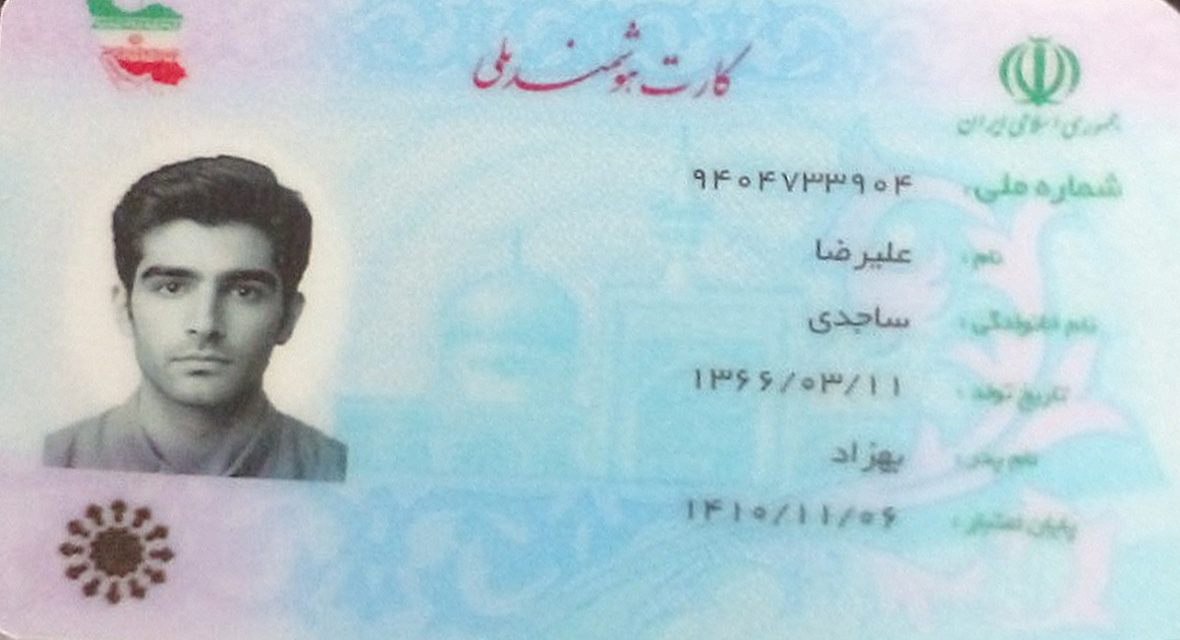


0: 352x640 1 Birth, 1 Expire, 1 FatherName, 1 LastName, 1 Name, 1 National, 11.2ms
Speed: 3.3ms preprocess, 11.2ms inference, 1.9ms postprocess per image at shape (1, 3, 352, 640)


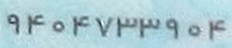

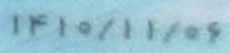

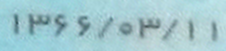

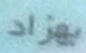

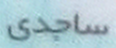

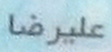

Label: National, Text: ۹۴۰۴۷۳۳۹۵۴, Confidence: 0.8831071257591248
Label: Expire, Text: آآا, Confidence: 0.8539517521858215
Label: Birth, Text: ۱آ/ن//؟ناا, Confidence: 0.837123692035675
Label: FatherName, Text: , Confidence: 0.8257426619529724
Label: LastName, Text: بداندی, Confidence: 0.8196422457695007
Label: Name, Text: لبرضا, Confidence: 0.8178832530975342
Error splitting Expire: آآا
Error splitting Birth: ۱آ/ن//؟ناا
ذخیره نهایی: 1 داده در فایل اصلی


[{'image_id': '43(1)',
  'national_id': '۹۴۰۴۷۳۳۹۵۴',
  'first_name': 'لبرضا',
  'last_name': 'بداندی',
  'birth_year': '',
  'birth_month': '',
  'birth_day': '',
  'father_name': '',
  'expiry_year': '',
  'expiry_month': '',
  'expiry_day': ''}]

In [ ]:
detect('/content/test/')

# Sort csv

In [ ]:
df = pd.read_csv('image_phase2.csv')
df = df.sort_values(by='image_id')
df.to_csv("image_phase2.csv", index=False)

In [ ]:
df

,image_id,national_id,first_name,last_name,birth_year,birth_month,birth_day,father_name,expiry_year,expiry_month,expiry_day
6,1,۶۰۲۴۸۴۰۳۹۶,سیامک,شهابی,۱۳۶۰,۰۵,۲۳,رایان,۱۲۱۰,۰۷,۱۶
9,7,۷۹۶۰۹۰۱۱۱۱,تت؟,مبتهه/هث,۱,۰۱,۱۸۷۱,بعه,۵۰,۴۰,۰۰۱۱
4,20,۴۲۷۱۵۵۴۰۵۷,کیان,الماسی,۱۳۸۱,۰۶,۱۱,مجید,۱۴۰۳,۰۷,۲۴
12,23,۴۵۱۸۷۰۵۳۲۷,پیام,شاهی,۱۳۷۹,۱۱,۲۰,یغما,۱۴۰۹,۰۷,۱۹
14,24,۵۱۶۱۳۰۸۶۰۵,سمیرا,اصفهانی,۱۳۶۶,۰۴,۲۳,شاهپور,۱۴۰۷,۰۲,۲۵
18,25,۶۷۷۴۸۶۷۹۱۹,پرهام,واعظی,۱۳۶۶,۰۶,۱۸,محسن,۱۴۱۴,۰۶,۲۲
15,26,۳۲۷۶۲۵۱۶۱۹,صدف,افشار,۱۳۶۷,۰۷,۲۶,ایوب,۱۴۰۹,۰۲,۰۴
16,27,۶۶۴۵۹۸۵۱۵۴,آرسوبرزن,دانایی,۱۳۸۴,۰۵,۰۶,شایان,۱۴۰۵,۰۴,۲۱
19,34,۴۰۶۳۴۵۷۲۰۶,گلئوش,یاورئ,۱۳۰۷۵,۰۸,۰۳,سهیل,۱۴۰۵,۸,۱۹
11,43,۹۴۰۴۷۳۳۹۵۴,لبرضا,بداندی,NaN,NaN,NaN,NaN,NaN,NaN,NaN
